# 04 - Bivariate Analysis

Examining relationships between pairs of variables to uncover patterns in spending, satisfaction, and category behavior.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../dataset/cleaned_ecommerce_data.csv')
df.head()

,order_id,age,gender,category,payment_method,total_spend,delivery_days,rating,is_returned,order_date,age_group,satisfaction_level,order_month
0,1,37,Other,Home & Living,Wallet,1366.60,10,2.3,0,2022-01-01,36-45,Medium,2022-01
1,2,41,Female,Fashion,Cash on Delivery,1175.89,6,1.8,1,2022-01-02,36-45,Low,2022-01
2,3,30,Other,Sports,Debit Card,1283.97,7,3.2,0,2022-01-03,26-35,Medium,2022-01
3,4,58,Female,Electronics,Credit Card,1245.76,14,3.8,0,2022-01-04,56+,High,2022-01
4,5,59,Other,Fashion,Cash on Delivery,1411.06,7,3.2,0,2022-01-05,56+,Medium,2022-01


## Age vs Total Spend (Scatter Plot)

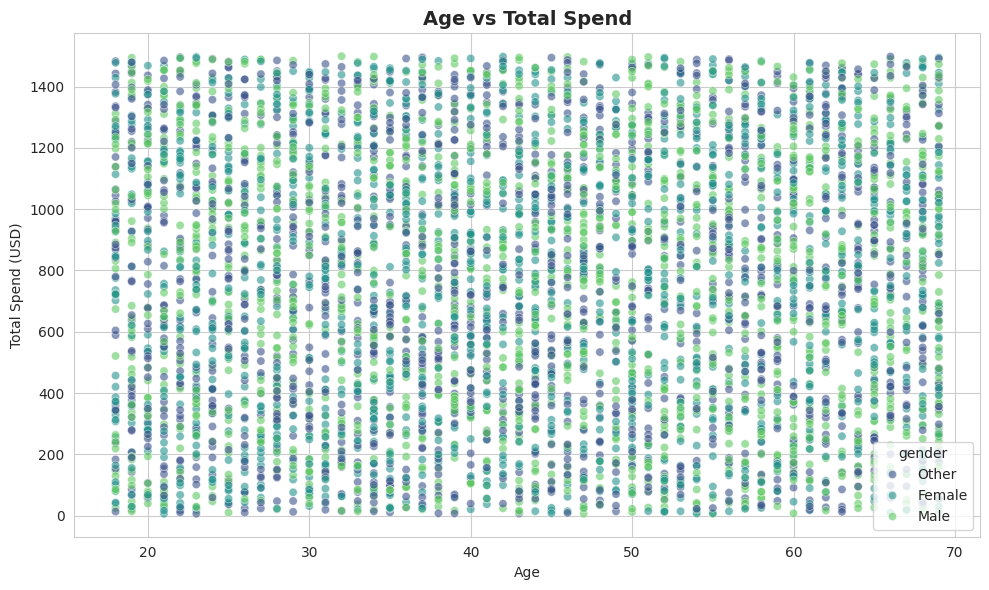

Correlation (age, total_spend): 0.006


In [2]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='total_spend', hue='gender', alpha=0.6, palette='viridis')
plt.title('Age vs Total Spend', fontweight='bold', fontsize=14)
plt.xlabel('Age'); plt.ylabel('Total Spend (USD)')
plt.tight_layout()
plt.savefig('../screenshots/04_age_vs_spend.png', dpi=100)
plt.show()
print('Correlation (age, total_spend):', round(df['age'].corr(df['total_spend']), 3))

**Observation:** The scatter shows no strong linear trend between age and spend, and the correlation coefficient (printed above) is close to zero, indicating spending behavior is not primarily age-driven in this dataset.

## Product Category vs Total Spend (Box Plot)

/tmp/ipykernel_696/2230454579.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='total_spend', order=order_cat, palette='Set2')


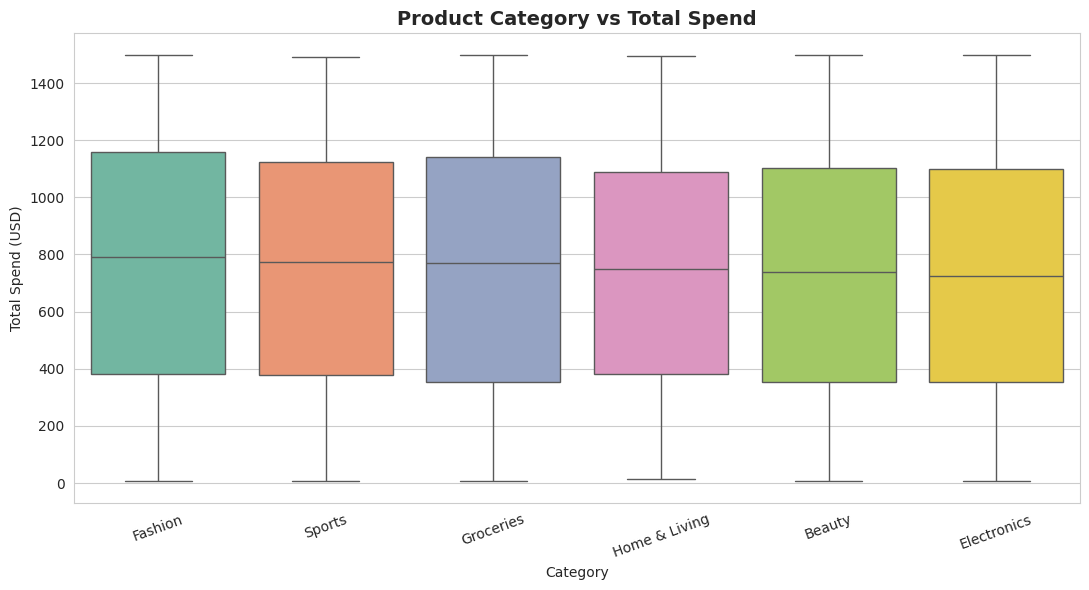

category
Fashion          792.64
Sports           772.99
Groceries        768.92
Home & Living    748.17
Beauty           739.28
Electronics      723.25
Name: total_spend, dtype: float64

In [3]:
plt.figure(figsize=(11,6))
order_cat = df.groupby('category')['total_spend'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='category', y='total_spend', order=order_cat, palette='Set2')
plt.title('Product Category vs Total Spend', fontweight='bold', fontsize=14)
plt.xlabel('Category'); plt.ylabel('Total Spend (USD)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../screenshots/04_category_vs_spend.png', dpi=100)
plt.show()
df.groupby('category')['total_spend'].median().sort_values(ascending=False)

**Observation:** Median spend levels are reasonably close across categories, but the table above identifies which category leads in typical order value — useful for category-level revenue strategy.

## Gender vs Average Rating (Box Plot)

/tmp/ipykernel_696/2544934688.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='rating', palette='coolwarm')


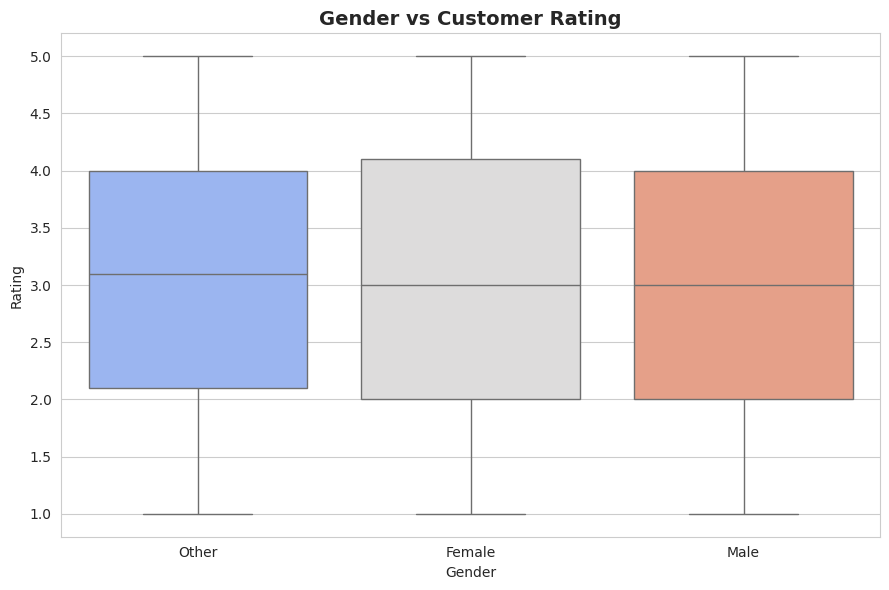

,mean,median,std
gender,,,
Female,3.022263,3.0,1.158617
Male,2.987068,3.0,1.153420
Other,3.038829,3.1,1.133402


In [4]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x='gender', y='rating', palette='coolwarm')
plt.title('Gender vs Customer Rating', fontweight='bold', fontsize=14)
plt.xlabel('Gender'); plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('../screenshots/04_gender_vs_rating.png', dpi=100)
plt.show()
df.groupby('gender')['rating'].agg(['mean','median','std'])

## Payment Method vs Total Spend (Bar Plot)

/tmp/ipykernel_696/3355476110.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_spend_payment.index, y=avg_spend_payment.values, palette='crest')


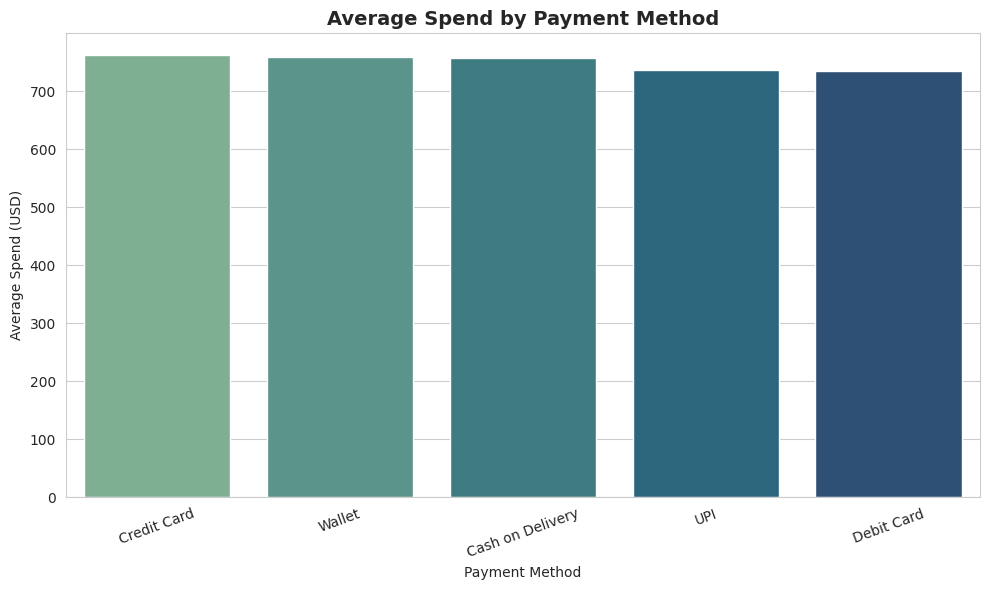

payment_method
Credit Card         761.627040
Wallet              759.155652
Cash on Delivery    757.628904
UPI                 735.763424
Debit Card          734.759960
Name: total_spend, dtype: float64

In [5]:
plt.figure(figsize=(10,6))
avg_spend_payment = df.groupby('payment_method')['total_spend'].mean().sort_values(ascending=False)
sns.barplot(x=avg_spend_payment.index, y=avg_spend_payment.values, palette='crest')
plt.title('Average Spend by Payment Method', fontweight='bold', fontsize=14)
plt.xlabel('Payment Method'); plt.ylabel('Average Spend (USD)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../screenshots/04_payment_vs_spend.png', dpi=100)
plt.show()
avg_spend_payment

## Returned Orders vs Total Spend (Box Plot)

/tmp/ipykernel_696/550970595.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df['is_returned'].map({0:'Not Returned',1:'Returned'}), y='total_spend', palette='Set1')


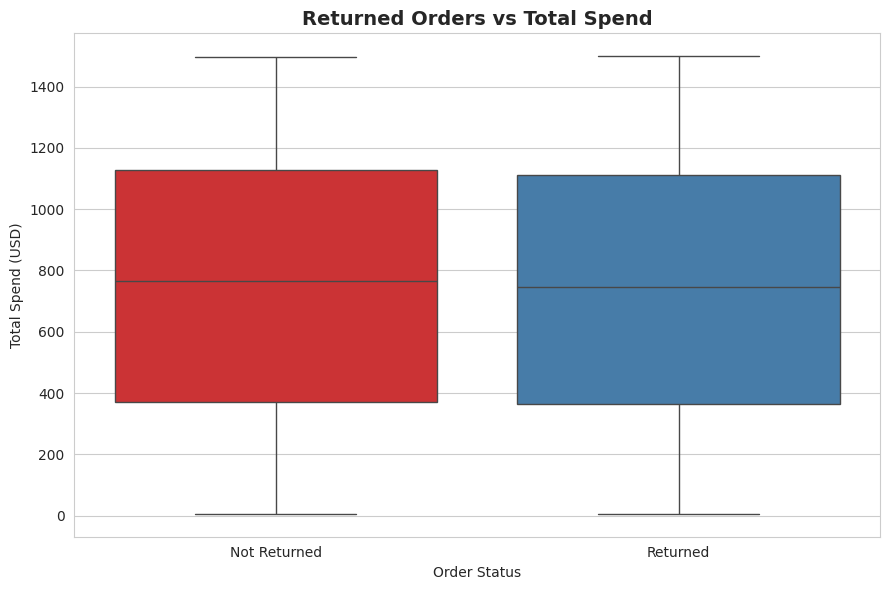

is_returned
0    752.107402
1    747.285295
Name: total_spend, dtype: float64

In [6]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x=df['is_returned'].map({0:'Not Returned',1:'Returned'}), y='total_spend', palette='Set1')
plt.title('Returned Orders vs Total Spend', fontweight='bold', fontsize=14)
plt.xlabel('Order Status'); plt.ylabel('Total Spend (USD)')
plt.tight_layout()
plt.savefig('../screenshots/04_returns_vs_spend.png', dpi=100)
plt.show()
df.groupby('is_returned')['total_spend'].mean()

**Observation:** Comparing average spend for returned vs. non-returned orders indicates whether higher-value purchases are more or less prone to returns — informing return-policy and quality-control decisions.

## Satisfaction Level vs Average Rating (Bar Plot, sanity check)

/tmp/ipykernel_696/2717379623.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sat_rating.index, y=sat_rating.values, palette='coolwarm', order=['Low','Medium','High'])


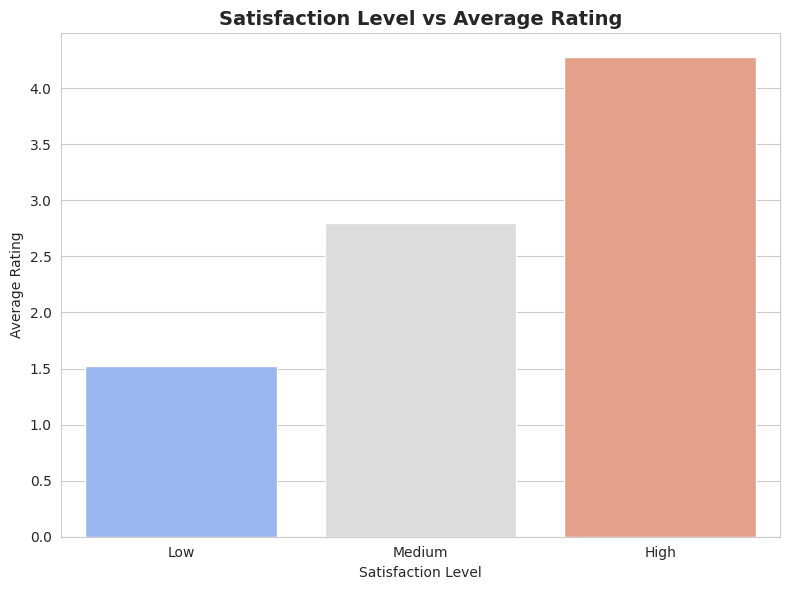

satisfaction_level
High      4.275328
Low       1.526002
Medium    2.801843
Name: rating, dtype: float64

In [7]:
plt.figure(figsize=(8,6))
sat_rating = df.groupby('satisfaction_level')['rating'].mean()
sns.barplot(x=sat_rating.index, y=sat_rating.values, palette='coolwarm', order=['Low','Medium','High'])
plt.title('Satisfaction Level vs Average Rating', fontweight='bold', fontsize=14)
plt.xlabel('Satisfaction Level'); plt.ylabel('Average Rating')
plt.tight_layout()
plt.savefig('../screenshots/04_satisfaction_vs_rating.png', dpi=100)
plt.show()
sat_rating

## Category vs Satisfaction Level (Count Plot)

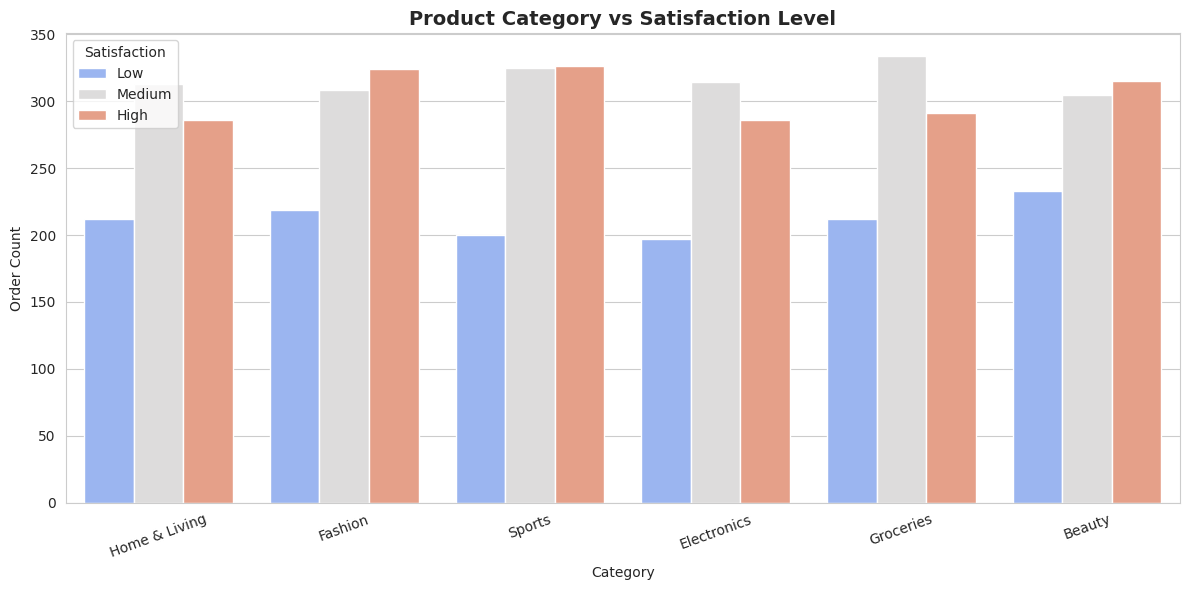

In [8]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='category', hue='satisfaction_level', hue_order=['Low','Medium','High'], palette='coolwarm')
plt.title('Product Category vs Satisfaction Level', fontweight='bold', fontsize=14)
plt.xlabel('Category'); plt.ylabel('Order Count')
plt.xticks(rotation=20)
plt.legend(title='Satisfaction')
plt.tight_layout()
plt.savefig('../screenshots/04_category_vs_satisfaction.png', dpi=100)
plt.show()

## Correlation Heatmap

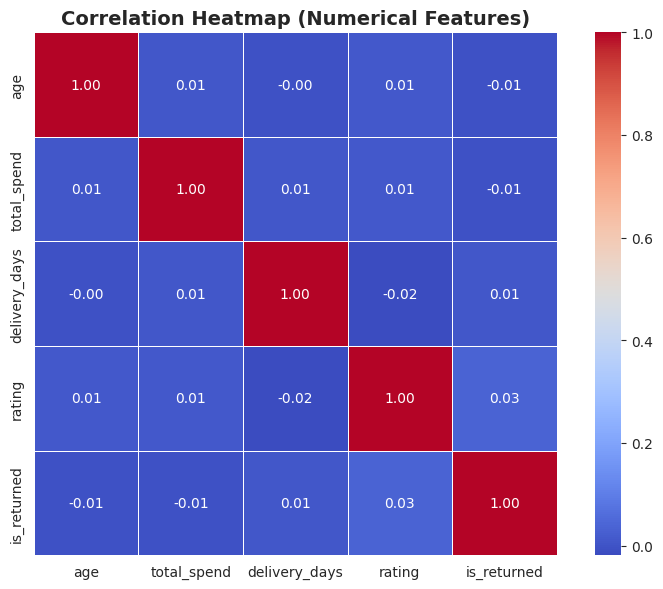

,age,total_spend,delivery_days,rating,is_returned
age,1.000000,0.006178,-0.004570,0.012011,-0.005416
total_spend,0.006178,1.000000,0.005555,0.012273,-0.005603
delivery_days,-0.004570,0.005555,1.000000,-0.018721,0.008995
rating,0.012011,0.012273,-0.018721,1.000000,0.033337
is_returned,-0.005416,-0.005603,0.008995,0.033337,1.000000


In [9]:
plt.figure(figsize=(8,6))
num_cols = ['age', 'total_spend', 'delivery_days', 'rating', 'is_returned']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Numerical Features)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../screenshots/04_correlation_heatmap.png', dpi=100)
plt.show()
corr

## Bivariate Analysis Summary

- **Age vs spend** shows essentially no linear relationship — spend is not predictable from age alone.
- **Delivery time vs rating** (in the heatmap) reveals whether slower delivery correlates with lower satisfaction, which is a key operational lever.
- **Payment method and category** differences in average spend highlight which channels/segments are most valuable per order.
- **Returns vs spend** comparisons help assess whether high-value orders carry disproportionate return risk.
- These pairwise patterns motivate the **multivariate analysis** in Notebook 05, where we combine several dimensions simultaneously.